# Finding Outliers

In [1]:
import os

import matplotlib.pyplot as plt
import seaborn as sn
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

## Dataset

In [2]:
# Read training and test data

earnings_df = pd.read_csv("fraud_data_new.csv")

In [3]:
earnings_df.sample(10)

,company_id,dsri,gmi,aqi,sgi,depi,sgai,accr,levi,status
805,806,1.969694,1.241748,1.066567,0.545718,0.856089,1.344165,-0.123904,1.973469,No
1165,1166,1.072629,1.305191,0.744922,1.245109,1.409104,0.872981,0.072200,1.461611,No
157,158,1.025815,1.036465,0.672899,0.982936,0.928981,1.107940,-0.049556,1.054705,No
947,948,3.756794,1.405289,1.005799,0.999879,1.017020,0.906033,0.104610,1.185430,No
182,183,1.129272,0.976220,0.943349,0.996769,1.044348,1.079466,-0.053915,1.020462,No
841,842,0.745580,0.982501,1.120939,1.139344,0.663365,1.014121,-0.015582,0.846457,No
131,132,1.559236,0.689389,1.178113,0.920385,1.044719,1.317414,-0.102983,0.937035,No
326,327,0.937589,1.023594,-0.561046,1.100212,1.039181,0.849666,-0.053878,0.907894,No
711,712,1.428170,0.866142,1.249325,0.835884,0.932648,1.017970,0.004431,0.936873,No
376,377,0.992555,0.960763,1.115868,1.125262,1.058983,1.572006,-0.014528,0.949855,No


In [4]:
earnings_df['status'] = earnings_df['status'].map(lambda x: 1 if x == 'Yes' else 0)

In [5]:
earnings_df.sample(10)

,company_id,dsri,gmi,aqi,sgi,depi,sgai,accr,levi,status
743,744,1.392672,0.931890,0.265653,1.976886,1.021197,0.614961,0.046993,0.476506,0
416,417,0.432499,0.854855,1.062474,1.222258,1.045524,1.212499,-0.021709,0.165646,0
80,81,1.186265,1.004056,1.601080,1.126169,0.988963,1.441029,0.065017,1.039612,0
859,860,0.990932,1.124261,0.979066,1.120354,0.998943,0.817368,-0.106209,0.980709,0
811,812,1.064053,0.826044,-0.199957,1.020206,1.070478,1.537122,-0.077126,0.952607,0
401,402,1.667149,0.996590,1.155873,0.766798,0.996105,1.178272,0.037710,0.647557,0
503,504,0.641073,0.973558,0.961978,1.039923,0.996372,1.025717,-3.143505,1.162535,0
1076,1077,0.108213,0.935567,1.450894,1.099720,1.080011,0.742393,-0.282315,0.737063,0
268,269,0.589834,1.060384,0.914007,1.378695,0.926637,1.078199,0.022619,1.068412,0
1135,1136,1.283847,1.229321,-0.763595,1.450927,0.758165,0.838699,0.200641,0.871859,0


In [6]:
earnings_df.status.value_counts()

,count
status,
0,1200
1,39


In [7]:
x_features = list(earnings_df.columns)
x_features.remove('company_id')
x_features.remove('status')

In [8]:
x_features

['dsri', 'gmi', 'aqi', 'sgi', 'depi', 'sgai', 'accr', 'levi']

In [9]:
earnings_df[x_features].shape

(1239, 8)

In [10]:
earnings_df['status'].shape

(1239,)

# Algorithms

## Isolation Forest

In [11]:
model = IsolationForest(n_estimators = 200,
                        contamination=0.1,
                        random_state=100)

model.fit(earnings_df[x_features])

IsolationForest(contamination=0.1, n_estimators=200, random_state=100)

In [12]:
scores = model.decision_function(earnings_df[x_features])

In [13]:
scores

array([-0.02617678, -0.22442569,  0.06856762, ...,  0.05864135,
        0.09748257,  0.08368201])

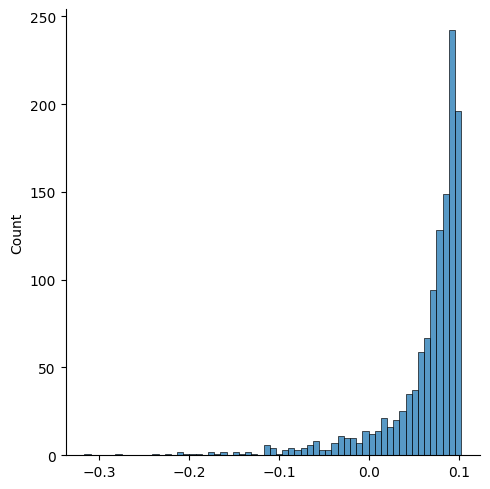

In [14]:
sn.displot(scores);

In [15]:
y_pred = model.predict(earnings_df[x_features])

y_pred_test = y = [1 if pred == -1 else 0 for pred in y_pred]

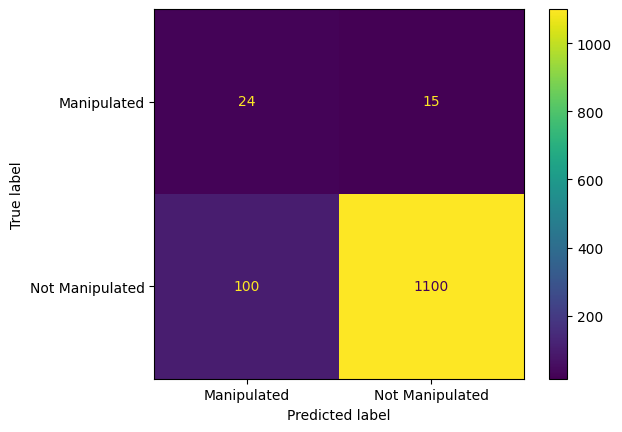

In [16]:
cm = confusion_matrix(earnings_df['status'],
                      y_pred_test,
                      labels = [1, 0])
cm_plot = ConfusionMatrixDisplay(cm, display_labels=['Manipulated', 'Not Manipulated'])
cm_plot.plot();

In [17]:
print("Classification Report:\n",
      classification_report(earnings_df['status'],
                            y_pred_test))

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.92      0.95      1200
           1       0.19      0.62      0.29        39

    accuracy                           0.91      1239
   macro avg       0.59      0.77      0.62      1239
weighted avg       0.96      0.91      0.93      1239



## Adjusting Contamination Values

In [18]:
threshold_vals = list(np.arange(0.05,
                                0.50,
                                0.05))

In [19]:
from sklearn.metrics import recall_score

In [20]:
threshold_recall = []

for threshold in threshold_vals:
    if_model = IsolationForest(n_estimators = 200,
                               contamination=threshold,
                               random_state=100)

    if_model.fit(earnings_df[x_features])

    y_pred = if_model.predict(earnings_df[x_features])

    y_pred_test = y = [1 if pred == -1 else 0 for pred in y_pred]

    threshold_recall.append([np.round(threshold, 3),
                             np.round(recall_score(earnings_df['status'],
                                                   y_pred_test), 2)])

In [21]:
threshold_recall_df = pd.DataFrame(threshold_recall,
                                   columns = ['threshold', 'recall'])

In [22]:
threshold_recall_df.sort_values("recall", ascending = False)

,threshold,recall
8,0.45,0.92
7,0.40,0.90
6,0.35,0.82
5,0.30,0.79
4,0.25,0.74
3,0.20,0.72
2,0.15,0.64
1,0.10,0.62
0,0.05,0.41
